# Q2 — Classificação do risco educacional municipal

Este notebook responde exclusivamente à pergunta:

> **Q2. Quais municípios apresentam maior risco educacional?**

A abordagem pactuada na EDA é **binária**:

- `risco_educacional = 1` quando `taxa_realizada < 50`;
- `risco_educacional = 0` quando `taxa_realizada >= 50`.

Esse corte representa a **baixa alfabetização** associada aos níveis oficiais 0 e 1.

O objetivo final da modelagem será estimar a **probabilidade futura de risco educacional** de cada município e, a partir dela, construir um ranking de priorização.

Neste primeiro trecho, porém, **nenhum modelo será treinado**. Antes disso, precisamos confirmar:

1. se o target está consistente com a regra pactuada;
2. como as classes estão distribuídas em 2024 e 2025;
3. quão estável é a condição de risco entre os dois anos;
4. qual estratégia de avaliação é mais adequada para a classificação.

A unidade de análise permanece **(município, ano)**.

## 1. Ambiente e leitura da base

A entrada é a base município-ano já preparada anteriormente:

`/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet`

O ano de **2024** será usado para desenvolvimento dos modelos.

O ano de **2025** será preservado como teste temporal final. Nesta etapa inicial, 2025 será observado apenas de forma **descritiva**, para entender a prevalência e a estabilidade do target; ele não será usado para treinar, selecionar ou otimizar modelos.

In [4]:
# Caso o computador tenho poder de processamento suficiente para a tarefa, troque o valor da variável AMBIENTE_COLAB para False.
AMBIENTE_COLAB = False

In [5]:
if AMBIENTE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    from src.config import PROCESSED_DATA_DIR

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

if AMBIENTE_COLAB:
    DIR_MODELAGEM = Path(
        '/content/drive/Othercomputers/@lua2026/01_projects/2026_FIAP/desafios/postech-challenge-3/data/processed/modelagem/dados_modelagem_municipio_ano_2024_2025.parquet'
    )

else:
    DIR_MODELAGEM = PROCESSED_DATA_DIR / 'modelagem'


if not DIR_MODELAGEM.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {DIR_MODELAGEM}\n'
        'Confirme se o Google Drive foi montado e se a base está no caminho esperado.'
    )

dados = pd.read_parquet(DIR_MODELAGEM)

print(f'Dimensões: {dados.shape[0]:,} linhas × {dados.shape[1]:,} colunas')
display(dados.head())

Dimensões: 11,073 linhas × 50 colunas


,ano,id_uf,id_municipio,nome_municipio,alunos,taxa_realizada,proficiencia_media,escolas,pct_rede_municipal,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atlas_idhm_longevidade,ctx_atlas_taxa_analfabetismo_11a14,ctx_atlas_taxa_analfabetismo_15a17,ctx_atlas_taxa_analfabetismo_15mais,ctx_atlas_taxa_frequencia_0a3,ctx_atlas_expectativa_anos_estudo,ctx_atlas_indice_gini,ctx_atlas_taxa_trabalho_infantil_10a14,ctx_atlas_taxa_maes_10a14,ctx_atlas_taxa_maes_chefes_familia,ctx_atlas_taxa_fora_escola_4a5,ctx_atlas_taxa_fora_escola_6a14,ctx_atlas_taxa_frequencia_liquida_fundamental,ctx_atlas_percentual_domicilios_agua,ctx_atlas_percentual_domicilios_energia,ctx_atlas_taxa_densidade_domiciliar,ctx_fundeb_nse_uf,populacao,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_media,taxa_lag1,proficiencia_lag1,participacao_lag1,meta,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,risco_educacional,risco_nao_atingir_meta,distancia_ate_a_meta,esforco_pactuado
0,2024,11,1100015,Alta Floresta D'Oeste,275,68.000,752.593,8,100.000,18.800,14.800,20.900,22.100,23.400,21.300,23.400,21.000,20.600,0.763,1.220,1.520,11.990,4.890,8.670,0.580,9.080,0.000,14.510,60.820,4.320,92.880,93.690,93.980,22.580,49.335,"22,853.000","7,067.127",0.397,0.005,"1,210.600",64.550,758.330,89.370,67.000,759.436,88.100,0.000,0.000,1.000,2.450
1,2024,11,1100023,Ariquemes,1066,65.854,748.307,18,100.000,23.500,20.500,25.200,25.000,24.900,23.200,25.800,26.000,25.500,0.806,1.550,1.090,7.900,9.890,9.180,0.530,7.890,0.000,18.070,44.660,2.790,91.310,98.540,98.580,27.150,49.335,"108,573.000","4,426.571",0.133,0.020,"1,458.570",62.300,757.100,89.790,65.000,759.436,88.100,0.000,0.000,0.854,2.700
2,2024,11,1100031,Cabixi,75,76.000,759.857,2,100.000,19.400,36.500,15.600,14.300,13.400,14.000,17.400,14.800,12.200,0.757,0.620,1.060,13.630,12.490,10.090,0.510,12.160,1.120,7.030,33.080,1.970,92.810,95.490,96.360,19.930,49.335,"5,690.000","1,314.352",0.468,0.016,"1,323.790",69.100,767.876,90.480,71.000,759.436,88.100,0.000,0.000,5.000,1.900
3,2024,11,1100049,Cacoal,951,66.351,747.937,19,83.701,17.400,17.700,17.300,20.721,21.593,22.260,21.662,17.402,19.280,0.821,1.010,0.800,8.290,11.380,9.740,0.570,11.800,0.680,12.800,37.590,2.390,93.020,97.960,98.890,20.500,49.335,"97,637.000","3,793.000",0.172,0.672,"1,625.880",62.510,755.564,84.440,65.000,759.436,88.100,0.000,0.000,1.351,2.490
4,2024,11,1100056,Cerejeiras,244,66.803,749.646,4,100.000,17.700,14.800,19.900,22.400,22.800,24.000,21.600,22.100,21.000,0.799,1.140,0.750,10.290,13.450,10.220,0.500,10.500,0.000,25.880,38.730,1.460,93.470,97.530,98.850,16.660,49.335,"16,975.000","2,783.300",0.112,0.580,"1,554.330",58.530,746.463,92.120,62.000,759.436,88.100,0.000,0.000,4.803,3.470


## 2. Auditoria mínima da unidade de análise

Antes de analisar o risco, validamos apenas o necessário para este notebook:

- presença de 2024 e 2025;
- presença das chaves `ano`, `id_uf` e `id_municipio`;
- ausência de duplicidade em `(id_municipio, ano)`.

Essa checagem evita interpretar como municípios distintos registros duplicados da mesma unidade de análise.

In [7]:
COLUNAS_CHAVE = ['ano', 'id_uf', 'id_municipio']
ANOS_ANALISE = [2024, 2025]

faltantes_chave = [c for c in COLUNAS_CHAVE if c not in dados.columns]
if faltantes_chave:
    raise KeyError(f'Colunas-chave ausentes: {faltantes_chave}')

anos_encontrados = sorted(dados['ano'].dropna().unique().tolist())
print('Anos encontrados:', anos_encontrados)

for ano in ANOS_ANALISE:
    if ano not in anos_encontrados:
        raise ValueError(f'O ano {ano} não está presente na base.')

duplicados = dados.duplicated(subset=['id_municipio', 'ano'], keep=False)

print(f'Duplicidades em (id_municipio, ano): {duplicados.sum():,}')

if duplicados.any():
    display(
        dados.loc[duplicados, COLUNAS_CHAVE]
        .sort_values(['id_municipio', 'ano'])
        .head(20)
    )
    raise ValueError(
        'Foram encontradas duplicidades na unidade município-ano. '
        'Corrija a base antes de continuar.'
    )

display(
    dados.groupby('ano')
    .size()
    .rename('municipios')
    .to_frame()
    .loc[ANOS_ANALISE]
)

Anos encontrados: [2024, 2025]
Duplicidades em (id_municipio, ano): 0


,municipios
ano,
2024,5517
2025,5556


## 3. Validação da definição do target de Q2

O target já existe na base como `risco_educacional`.

A regra pactuada na EDA é:

```python
risco_educacional = 1  # taxa_realizada < 50
risco_educacional = 0  # taxa_realizada >= 50
```

Neste notebook **não redefinimos o corte**. Apenas verificamos se o target salvo na base respeita exatamente essa regra.

`taxa_realizada` é utilizada aqui **somente para auditar o target**. Ela não poderá entrar como feature do modelo porque determina diretamente a classe que queremos prever.

In [8]:
TARGET_Q2 = 'risco_educacional'
COLUNA_TAXA = 'taxa_realizada'

colunas_obrigatorias = [TARGET_Q2, COLUNA_TAXA]
faltantes = [c for c in colunas_obrigatorias if c not in dados.columns]

if faltantes:
    raise KeyError(f'Colunas obrigatórias ausentes para Q2: {faltantes}')

base_validacao_target = dados.loc[
    dados[TARGET_Q2].notna() & dados[COLUNA_TAXA].notna(),
    ['ano', 'id_uf', 'id_municipio', COLUNA_TAXA, TARGET_Q2]
].copy()

target_esperado = (
    base_validacao_target[COLUNA_TAXA] < 50
).astype(int)

target_observado = pd.to_numeric(
    base_validacao_target[TARGET_Q2],
    errors='coerce'
)

valores_target = sorted(target_observado.dropna().unique().tolist())
print('Valores observados no target:', valores_target)

if not set(valores_target).issubset({0, 1}):
    raise ValueError(
        f'O target deveria ser binário (0/1), mas foram encontrados: {valores_target}'
    )

divergencia = target_observado.ne(target_esperado)
n_divergencias = int(divergencia.sum())

print(f'Observações auditadas: {len(base_validacao_target):,}')
print(f'Divergências com a regra taxa_realizada < 50: {n_divergencias:,}')

if n_divergencias > 0:
    display(
        base_validacao_target.loc[divergencia]
        .assign(risco_esperado=target_esperado.loc[divergencia])
        .head(20)
    )
    raise ValueError(
        'O target risco_educacional não está consistente com o corte pactuado de 50%. '
        'A modelagem deve parar até essa inconsistência ser corrigida.'
    )

print('Target validado: risco_educacional está consistente com taxa_realizada < 50%.')

Valores observados no target: [0.0, 1.0]
Observações auditadas: 11,073
Divergências com a regra taxa_realizada < 50: 0
Target validado: risco_educacional está consistente com taxa_realizada < 50%.


## Controle de features antes da modelagem

Antes do treinamento, as colunas são separadas pelo **motivo da exclusão**:

1. **Identificadores** — usados para rastreabilidade e apresentação, não como preditores;
2. **Variáveis com vazamento** — contêm informação do resultado atual ou derivada diretamente dele;
3. **Variáveis excluídas pela política Q1/Q2** — não são necessariamente vazamento, mas foram retiradas para manter o conjunto estrutural definido no projeto e preservar a separação entre risco educacional e metas pactuadas.

A tabela exibida ao final desta etapa contém **somente as features efetivamente utilizadas pela Q2**.


In [9]:
# ============================================================
# Controle de features antes da modelagem
# ============================================================

IDENTIFICADORES_Q2 = [
    'ano',
    'id_uf',
    'id_municipio',
    'nome_municipio',
]

VAZAMENTO_Q2 = [
    'risco_educacional',
    'taxa_realizada',
    'nivel_realizado',
    'proficiencia_media',
    'distancia_ate_a_meta',
    'variacao_ica',
    'risco_nao_atingir_meta',
]

# Não são necessariamente vazamento. Foram excluídas para manter a política
# estrutural de features definida no Q1/Q2 e separar a Q2 das metas pactuadas.
EXCLUIDAS_POLITICA_Q2 = [
    'alunos',
    'escolas',
    'pct_rede_municipal',
    'meta',
    'esforco_pactuado',
]

identificadores_presentes = [
    c for c in IDENTIFICADORES_Q2 if c in dados.columns
]
vazamento_presente = [
    c for c in VAZAMENTO_Q2 if c in dados.columns
]
excluidas_politica_presentes = [
    c for c in EXCLUIDAS_POLITICA_Q2 if c in dados.columns
]

FEATURES_Q2 = sorted([
    c for c in dados.columns
    if c not in set(
        identificadores_presentes
        + vazamento_presente
        + excluidas_politica_presentes
    )
])

print(f'Features finais utilizadas pela Q2: {len(FEATURES_Q2)}')

print('\nIdentificadores excluídos:')
print(identificadores_presentes)

print('\nVariáveis excluídas por vazamento:')
print(vazamento_presente)

print('\nVariáveis excluídas pela política de features Q1/Q2:')
print(excluidas_politica_presentes)

print('\nFeatures finais utilizadas pela Q2:')
display(pd.DataFrame({'feature': FEATURES_Q2}))

# Validações: nenhuma coluna proibida pode chegar ao modelo.
assert not set(identificadores_presentes).intersection(FEATURES_Q2)
assert not set(vazamento_presente).intersection(FEATURES_Q2)
assert not set(excluidas_politica_presentes).intersection(FEATURES_Q2)
assert 'nome_municipio' not in FEATURES_Q2

Features finais utilizadas pela Q2: 36

Identificadores excluídos:
['ano', 'id_uf', 'id_municipio', 'nome_municipio']

Variáveis excluídas por vazamento:
['risco_educacional', 'taxa_realizada', 'proficiencia_media', 'distancia_ate_a_meta', 'risco_nao_atingir_meta']

Variáveis excluídas pela política de features Q1/Q2:
['alunos', 'escolas', 'pct_rede_municipal', 'meta', 'esforco_pactuado']

Features finais utilizadas pela Q2:


,feature
0,ctx_atlas_expectativa_anos_estudo
1,ctx_atlas_idhm_longevidade
2,ctx_atlas_indice_gini
3,ctx_atlas_percentual_domicilios_agua
4,ctx_atlas_percentual_domicilios_energia
5,ctx_atlas_taxa_analfabetismo_11a14
6,ctx_atlas_taxa_analfabetismo_15a17
7,ctx_atlas_taxa_analfabetismo_15mais
8,ctx_atlas_taxa_densidade_domiciliar
9,ctx_atlas_taxa_fora_escola_4a5


## 5. Distribuição do risco educacional

Agora observamos a prevalência do target em cada ano.

Esta análise responde duas perguntas simples:

1. quantos municípios pertencem à classe de risco;
2. se existe desbalanceamento relevante entre `risco = 1` e `risco = 0`.

A **accuracy não deve ser escolhida como métrica principal apenas por conveniência**. Se a classe de risco for minoritária, um classificador pode alcançar accuracy alta simplesmente acertando a classe majoritária, sem identificar adequadamente os municípios que mais importam para a política pública.

In [10]:
base_target = dados.loc[
    dados['ano'].isin(ANOS_ANALISE) & dados[TARGET_Q2].notna(),
    ['ano', 'id_municipio', TARGET_Q2]
].copy()

base_target[TARGET_Q2] = pd.to_numeric(
    base_target[TARGET_Q2],
    errors='raise'
).astype(int)

distribuicao_q2 = (
    base_target
    .groupby(['ano', TARGET_Q2])
    .size()
    .rename('municipios')
    .reset_index()
)

totais_ano = (
    base_target.groupby('ano')
    .size()
    .rename('total_municipios')
)

distribuicao_q2['percentual'] = (
    distribuicao_q2['municipios']
    / distribuicao_q2['ano'].map(totais_ano)
    * 100
)

distribuicao_q2['classe'] = distribuicao_q2[TARGET_Q2].map({
    0: 'Fora do risco (>= 50%)',
    1: 'Risco (< 50%)',
})

tabela_distribuicao_q2 = (
    distribuicao_q2[
        ['ano', 'classe', 'municipios', 'percentual']
    ]
    .sort_values(['ano', 'classe'])
    .reset_index(drop=True)
)

display(tabela_distribuicao_q2)

,ano,classe,municipios,percentual
0,2024,Fora do risco (>= 50%),4092,74.171
1,2024,Risco (< 50%),1425,25.829
2,2025,Fora do risco (>= 50%),5059,91.055
3,2025,Risco (< 50%),497,8.945


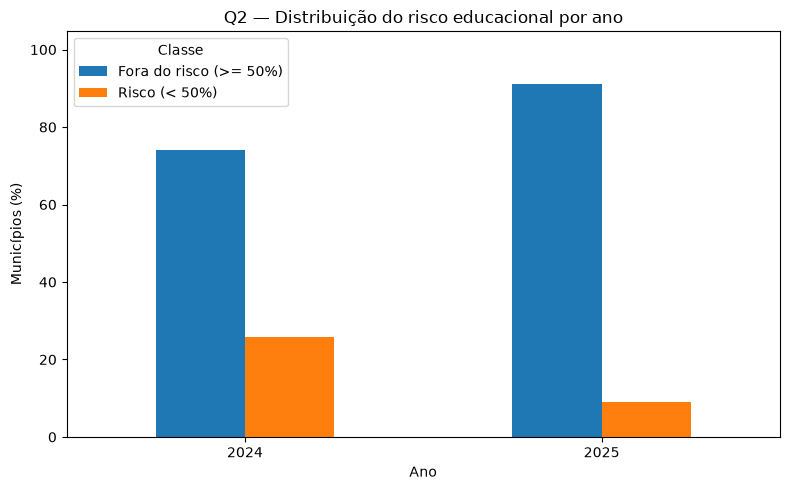

In [11]:
grafico_q2 = (
    distribuicao_q2
    .pivot(index='ano', columns='classe', values='percentual')
    .fillna(0)
)

ax = grafico_q2.plot(
    kind='bar',
    figsize=(8, 5)
)

ax.set_title('Q2 — Distribuição do risco educacional por ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Municípios (%)')
ax.set_ylim(0, max(100, grafico_q2.to_numpy().max() * 1.15))
ax.legend(title='Classe')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Estabilidade temporal do target

*   List item
*   List item



Além da distribuição em cada ano, precisamos saber quantos municípios mudaram de condição entre 2024 e 2025.

Consideramos somente os municípios:

- presentes nos dois anos;
- com `risco_educacional` não nulo nos dois anos.

As quatro situações possíveis são:

- fora do risco → fora do risco;
- fora do risco → risco;
- risco → fora do risco;
- risco → risco.

Essa tabela **não avalia nenhum modelo**. Ela apenas descreve a estabilidade da variável que futuramente queremos prever.

In [12]:
risco_por_ano = (
    base_target
    .pivot(index='id_municipio', columns='ano', values=TARGET_Q2)
    .dropna(subset=[2024, 2025])
    .rename(columns={
        2024: 'risco_2024',
        2025: 'risco_2025',
    })
    .astype(int)
)

rotulo = {
    0: 'Fora do risco',
    1: 'Risco',
}

risco_por_ano['transicao'] = (
    risco_por_ano['risco_2024'].map(rotulo)
    + ' → '
    + risco_por_ano['risco_2025'].map(rotulo)
)

transicoes_q2 = (
    risco_por_ano['transicao']
    .value_counts()
    .rename('municipios')
    .to_frame()
)

transicoes_q2['percentual'] = (
    transicoes_q2['municipios']
    / len(risco_por_ano)
    * 100
)

print(f'Municípios comparáveis em 2024 e 2025: {len(risco_por_ano):,}')
display(transicoes_q2)

n_entrou_risco = int(
    ((risco_por_ano['risco_2024'] == 0) &
     (risco_por_ano['risco_2025'] == 1)).sum()
)

n_saiu_risco = int(
    ((risco_por_ano['risco_2024'] == 1) &
     (risco_por_ano['risco_2025'] == 0)).sum()
)

n_permaneceu_risco = int(
    ((risco_por_ano['risco_2024'] == 1) &
     (risco_por_ano['risco_2025'] == 1)).sum()
)

print(f'Fora do risco → risco: {n_entrou_risco:,}')
print(f'Risco → fora do risco: {n_saiu_risco:,}')
print(f'Permaneceu em risco:   {n_permaneceu_risco:,}')

Municípios comparáveis em 2024 e 2025: 5,509


,municipios,percentual
transicao,,
Fora do risco → Fora do risco,4007,72.736
Risco → Fora do risco,1024,18.588
Risco → Risco,398,7.225
Fora do risco → Risco,80,1.452


Fora do risco → risco: 80
Risco → fora do risco: 1,024
Permaneceu em risco:   398


## 7. Conclusão parcial — estratégia de avaliação da classificação

Os outputs anteriores permitem encerrar o primeiro ponto de decisão.

Em **2024**, ano usado para desenvolvimento, a classe de risco representa **25,829%** dos municípios
(1.425 de 5.517). Portanto, existe desbalanceamento relevante: aproximadamente três quartos dos municípios
pertencem à classe `0`.

Em **2025**, a prevalência do risco cai para **8,945%** (497 de 5.556), mostrando uma mudança temporal importante
na distribuição do target.

Entre os 5.509 municípios comparáveis nos dois anos:

- 4.007 permaneceram fora do risco (**72,736%**);
- 1.024 passaram de risco para fora do risco (**18,588%**);
- 398 permaneceram em risco (**7,225%**);
- 80 passaram de fora do risco para risco (**1,452%**).

Essa mudança reforça que o teste temporal de 2025 será importante: a classificação precisa funcionar em um período
em que a classe positiva é ainda mais rara.

### Decisão de avaliação

A métrica principal será o **Recall da classe de risco (`risco_educacional = 1`)**.

Ela responde diretamente:

> Entre os municípios que realmente estão em risco, quantos o modelo consegue identificar?

Essa escolha é adequada ao objetivo de priorização, porque um **falso negativo** representa um município realmente
em risco que não seria sinalizado pelo modelo.

Entretanto, Recall não será analisado isoladamente. As métricas complementares serão:

- **Precision** — controla quantos alertas de risco são corretos;
- **F1-score** — resume o equilíbrio entre Recall e Precision;
- **PR-AUC / Average Precision** — especialmente útil com classe positiva minoritária;
- **ROC-AUC** — avalia a capacidade geral de ordenação das classes;
- **Accuracy** — será mostrada apenas como métrica descritiva.

Como 2024 já apresenta desbalanceamento, serão comparadas versões **padrão** e **`class_weight='balanced'`**
dos classificadores que suportam esse parâmetro. O balanceamento não será assumido como melhor: a validação cruzada
de 2024 deverá mostrar se ele melhora a identificação da classe de risco sem perda excessiva de Precision.

Não será utilizado SMOTE neste primeiro ciclo.

## 8. Revisão final das features de Q2

Antes de treinar os classificadores, aplicamos a mesma disciplina usada em Q1.

### Exclusão por vazamento direto ou informação corrente

Estas colunas não podem ser utilizadas para prever `risco_educacional` porque representam o próprio resultado,
determinam diretamente o target ou são derivações do resultado corrente:

- `risco_educacional`;
- `taxa_realizada`;
- `nivel_realizado`;
- `proficiencia_media`;
- `distancia_ate_a_meta`;
- `variacao_ica`;
- `risco_nao_atingir_meta`.

### Identificadores

`ano`, `id_uf`, `id_municipio` e `nome_municipio` são mantidos apenas para rastreabilidade e para o ranking final.

### Variáveis fora do conjunto estrutural

Para manter Q2 consistente com a modelagem de Q1, também ficam fora do conjunto preditivo estrutural:

- `alunos`;
- `escolas`;
- `pct_rede_municipal`;
- `meta`;
- `esforco_pactuado`.

Essas variáveis não são todas classificadas como *leakage*. A exclusão serve para manter Q2 focado em fatores
estruturais e históricos disponíveis antes do resultado, sem misturar a pergunta de risco educacional com
cumprimento de meta/pactuação.

Features defasadas, como `taxa_lag1`, `proficiencia_lag1` e `participacao_lag1`, permanecem elegíveis porque
representam informação anterior ao resultado previsto.

In [13]:
FEATURES_PROIBIDAS_Q2 = {
    # Target e resultados/derivações correntes
    'risco_educacional',
    'taxa_realizada',
    'nivel_realizado',
    'proficiencia_media',
    'distancia_ate_a_meta',
    'variacao_ica',
    'risco_nao_atingir_meta',

    # Identificadores
    'ano',
    'id_uf',
    'id_municipio',
    'nome_municipio',
}

FEATURES_FORA_CONJUNTO_ESTRUTURAL_Q2 = {
    'alunos',
    'escolas',
    'pct_rede_municipal',
    'meta',
    'esforco_pactuado',
}

FEATURES_Q2 = sorted([
    c for c in dados.columns
    if c not in FEATURES_PROIBIDAS_Q2
    and c not in FEATURES_FORA_CONJUNTO_ESTRUTURAL_Q2
])

vazamento_encontrado = set(FEATURES_Q2) & FEATURES_PROIBIDAS_Q2
assert not vazamento_encontrado, (
    f'Leakage encontrado em FEATURES_Q2: {sorted(vazamento_encontrado)}'
)

print(f'Features finais de Q2: {len(FEATURES_Q2)}')

print('\nExcluídas por target/leakage/identificação:')
print(sorted(c for c in FEATURES_PROIBIDAS_Q2 if c in dados.columns))

print('\nFora do conjunto estrutural:')
print(sorted(c for c in FEATURES_FORA_CONJUNTO_ESTRUTURAL_Q2 if c in dados.columns))

print('\nFeatures utilizadas:')
display(pd.DataFrame({'feature': FEATURES_Q2}))

Features finais de Q2: 36

Excluídas por target/leakage/identificação:
['ano', 'distancia_ate_a_meta', 'id_municipio', 'id_uf', 'nome_municipio', 'proficiencia_media', 'risco_educacional', 'risco_nao_atingir_meta', 'taxa_realizada']

Fora do conjunto estrutural:
['alunos', 'escolas', 'esforco_pactuado', 'meta', 'pct_rede_municipal']

Features utilizadas:


,feature
0,ctx_atlas_expectativa_anos_estudo
1,ctx_atlas_idhm_longevidade
2,ctx_atlas_indice_gini
3,ctx_atlas_percentual_domicilios_agua
4,ctx_atlas_percentual_domicilios_energia
5,ctx_atlas_taxa_analfabetismo_11a14
6,ctx_atlas_taxa_analfabetismo_15a17
7,ctx_atlas_taxa_analfabetismo_15mais
8,ctx_atlas_taxa_densidade_domiciliar
9,ctx_atlas_taxa_fora_escola_4a5


## 9. Preparação do desenvolvimento em 2024

A seleção e comparação dos modelos será feita **somente com 2024**.

O ano de 2025 não será acessado nesta etapa.

O pré-processamento será simples:

- variáveis numéricas: imputação pela mediana;
- variáveis categóricas: imputação pela moda + One-Hot Encoding;
- Regressão Logística: recebe também padronização das variáveis numéricas;
- Árvore e Random Forest: não precisam de scaling.

Todo pré-processamento que aprende parâmetros dos dados permanece dentro do `Pipeline`, evitando vazamento entre
os folds da validação cruzada.

In [14]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

DADOS_2024 = dados.loc[dados['ano'].eq(2024)].copy()

idx_q2_2024 = DADOS_2024.index[DADOS_2024[TARGET_Q2].notna()]

X_q2_2024 = DADOS_2024.loc[idx_q2_2024, FEATURES_Q2].copy()
y_q2_2024 = (
    pd.to_numeric(DADOS_2024.loc[idx_q2_2024, TARGET_Q2], errors='raise')
    .astype(int)
)

colunas_chave_q2 = ['ano', 'id_uf', 'id_municipio', 'nome_municipio']

chaves_q2_2024 = DADOS_2024.loc[
    idx_q2_2024,
    colunas_chave_q2
].copy()

assert X_q2_2024.index.equals(y_q2_2024.index)
assert not y_q2_2024.isna().any()
assert set(y_q2_2024.unique()).issubset({0, 1})

print('Desenvolvimento Q2 — 2024')
print(f'X: {X_q2_2024.shape}')
print(f'Classe de risco: {y_q2_2024.sum():,} ({y_q2_2024.mean() * 100:.1f}%)')

Desenvolvimento Q2 — 2024
X: (5517, 36)
Classe de risco: 1,425 (25.8%)


In [15]:
pipeline_numerico_logistica = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
    ('scaler', StandardScaler()),
])

pipeline_numerico_arvore = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
])

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
        )
    ),
])

seletor_numerico = make_column_selector(dtype_include=np.number)
seletor_categorico = make_column_selector(dtype_exclude=np.number)

preprocessor_logistica = ColumnTransformer([
    ('num', pipeline_numerico_logistica, seletor_numerico),
    ('cat', pipeline_categorico, seletor_categorico),
])

preprocessor_arvore = ColumnTransformer([
    ('num', pipeline_numerico_arvore, seletor_numerico),
    ('cat', pipeline_categorico, seletor_categorico),
])

## 10. Baseline e modelos candidatos

A comparação inicial será deliberadamente pequena e auditável:

1. **Baseline** — sempre prevê a classe majoritária;
2. **Regressão Logística** — modelo simples e interpretável;
3. **Árvore de Decisão** — captura relações não lineares;
4. **Random Forest** — agrega várias árvores para melhorar estabilidade e desempenho.

Para Regressão Logística, Árvore e Random Forest serão avaliadas:

- versão padrão;
- versão com `class_weight='balanced'`.

Assim, o efeito do balanceamento será observado nos dados de 2024 em vez de ser assumido previamente.

In [16]:
cv_classificacao = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Scorers explícitos evitam warnings quando um modelo não prevê positivos,
# como pode ocorrer com o baseline de classe majoritária.
scoring_classificacao = {
    'recall': make_scorer(recall_score, pos_label=1, zero_division=0),
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1': make_scorer(f1_score, pos_label=1, zero_division=0),
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
}

modelos_q2 = {
    'Baseline classe majoritária': DummyClassifier(
        strategy='most_frequent'
    ),

    'Regressão Logística': Pipeline([
        ('preprocessor', preprocessor_logistica),
        (
            'model',
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE,
            )
        ),
    ]),

    'Regressão Logística balanceada': Pipeline([
        ('preprocessor', preprocessor_logistica),
        (
            'model',
            LogisticRegression(
                max_iter=2000,
                class_weight='balanced',
                random_state=RANDOM_STATE,
            )
        ),
    ]),

    'Árvore de Decisão': Pipeline([
        ('preprocessor', preprocessor_arvore),
        (
            'model',
            DecisionTreeClassifier(
                random_state=RANDOM_STATE,
            )
        ),
    ]),

    'Árvore de Decisão balanceada': Pipeline([
        ('preprocessor', preprocessor_arvore),
        (
            'model',
            DecisionTreeClassifier(
                class_weight='balanced',
                random_state=RANDOM_STATE,
            )
        ),
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_arvore),
        (
            'model',
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
    ]),

    'Random Forest balanceada': Pipeline([
        ('preprocessor', preprocessor_arvore),
        (
            'model',
            RandomForestClassifier(
                n_estimators=300,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
    ]),
}

In [17]:
def resumir_cv_classificacao(nome, resultado):
    recall_treino = np.mean(resultado['train_recall'])
    recall_cv = np.mean(resultado['test_recall'])

    return {
        'modelo': nome,
        'Recall_treino': recall_treino,
        'Recall_CV': recall_cv,
        'Recall_CV_std': np.std(resultado['test_recall']),
        'gap_Recall': recall_treino - recall_cv,
        'Precision_CV': np.mean(resultado['test_precision']),
        'F1_CV': np.mean(resultado['test_f1']),
        'PR_AUC_CV': np.mean(resultado['test_pr_auc']),
        'ROC_AUC_CV': np.mean(resultado['test_roc_auc']),
        'Accuracy_CV': np.mean(resultado['test_accuracy']),
    }


resultados_q2 = []

for nome, modelo in modelos_q2.items():
    resultado = cross_validate(
        modelo,
        X_q2_2024,
        y_q2_2024,
        cv=cv_classificacao,
        scoring=scoring_classificacao,
        return_train_score=True,
        n_jobs=-1,
    )

    resultados_q2.append(
        resumir_cv_classificacao(nome, resultado)
    )

comparacao_q2 = (
    pd.DataFrame(resultados_q2)
    .sort_values(
        ['Recall_CV', 'PR_AUC_CV', 'F1_CV'],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(comparacao_q2.round(3))

,modelo,Recall_treino,Recall_CV,Recall_CV_std,gap_Recall,Precision_CV,F1_CV,PR_AUC_CV,ROC_AUC_CV,Accuracy_CV
0,Regressão Logística balanceada,0.781,0.775,0.014,0.006,0.608,0.681,0.741,0.883,0.813
1,Random Forest balanceada,1.000,0.732,0.023,0.268,0.715,0.723,0.802,0.916,0.855
2,Árvore de Decisão,1.000,0.629,0.021,0.371,0.615,0.622,0.483,0.746,0.802
3,Random Forest,1.000,0.626,0.027,0.374,0.799,0.701,0.804,0.914,0.863
4,Árvore de Decisão balanceada,1.000,0.614,0.018,0.386,0.604,0.609,0.471,0.737,0.796
5,Regressão Logística,0.606,0.600,0.009,0.006,0.743,0.663,0.745,0.882,0.843
6,Baseline classe majoritária,0.000,0.000,0.000,0.000,0.000,0.000,0.258,0.500,0.742


### Como ler a tabela

A tabela **não escolhe automaticamente o vencedor**.

A leitura deve começar pelo `Recall_CV`, porque a prioridade é não deixar municípios realmente em risco sem sinalização.

Depois, verifique:

- `Precision_CV`: um Recall alto não deve vir acompanhado de alertas excessivamente imprecisos;
- `F1_CV`: resume o compromisso entre Recall e Precision;
- `PR_AUC_CV`: importante para avaliar a ordenação da classe positiva em um problema desbalanceado;
- `ROC_AUC_CV`: visão complementar da separação das classes;
- `gap_Recall`: diferença entre Recall de treino e validação; valores muito altos podem indicar sobreajuste;
- `Recall_CV_std`: mostra a estabilidade do Recall entre os cinco folds;
- `Accuracy_CV`: apenas descritiva, não é a métrica de decisão.

Compare também cada versão padrão com sua versão `class_weight='balanced'`. O balanceamento só deve ser mantido se trouxer
ganho útil na identificação da classe de risco sem deteriorar excessivamente as demais métricas.

## 11. Conclusão parcial — escolha do modelo

A comparação em validação cruzada de 2024 permite encerrar o segundo ponto de decisão.

A **Regressão Logística balanceada** apresentou:

- `Recall_CV = 0,775`;
- `Precision_CV = 0,608`;
- `F1_CV = 0,681`;
- `PR_AUC_CV = 0,741`;
- `ROC_AUC_CV = 0,883`;
- `Recall_CV_std = 0,014`;
- `gap_Recall = 0,006`.

O principal ganho em relação à Regressão Logística padrão ocorreu no Recall:

- Logística padrão: `Recall_CV = 0,600`;
- Logística balanceada: `Recall_CV = 0,775`.

O aumento do Recall veio acompanhado de redução da Precision, de `0,743` para `0,608`. Esse trade-off é aceitável
para a Q2 porque a prioridade definida no primeiro ponto de controle é reduzir falsos negativos — municípios realmente
em risco que deixariam de ser sinalizados.

A Regressão Logística balanceada também mostrou boa estabilidade: seu Recall de treino (`0,781`) ficou muito próximo
do Recall de validação (`0,775`), com `gap = 0,006`.

A Random Forest apresentou PR-AUC e ROC-AUC superiores, mas mostrou sobreajuste importante:

- Random Forest: `Recall_treino = 1,000` e `Recall_CV = 0,626`;
- Random Forest balanceada: `Recall_treino = 1,000` e `Recall_CV = 0,589`.

As Árvores de Decisão apresentaram comportamento semelhante de sobreajuste e métricas de ranking inferiores.

### Decisão

Seguiremos com:

> **Regressão Logística com `class_weight='balanced'`**

Não será realizado tuning neste momento.

A decisão privilegia:

1. maior Recall em validação;
2. baixa variação entre folds;
3. ausência de sinal relevante de sobreajuste;
4. simplicidade e interpretabilidade compatíveis com um pipeline para analista Jr.

O próximo passo é congelar essa decisão e testar **exatamente esse modelo**, com o threshold padrão de `0,5`,
no ano de 2025.

Nenhuma escolha adicional de modelo, hiperparâmetro ou threshold será feita utilizando 2025.

### 11.1 Baseline de validação em 2024 — predições out-of-fold

Antes de abrir 2025, registramos uma referência de desempenho usando **predições out-of-fold (OOF)** da
Regressão Logística balanceada em 2024.

Em cada fold, o município é previsto por um modelo que **não utilizou aquele registro no ajuste**. Portanto,
essa avaliação é adequada para estimar o desempenho dentro da janela de desenvolvimento sem recorrer a
predições *in-sample*.

> Esta etapa **não é um teste in-time independente**. Trata-se de uma validação OOF de 2024, construída com o
> mesmo `StratifiedKFold` usado na comparação dos modelos.

O threshold permanece o padrão definido para Q2 (`0,50`). As predições OOF serão usadas apenas para formar uma
baseline diretamente comparável à matriz de confusão e às métricas do teste temporal de 2025.

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

MODELO_ESCOLHIDO_Q2 = modelos_q2['Regressão Logística balanceada']
THRESHOLD_Q2 = 0.50

probabilidade_risco_oof_2024 = cross_val_predict(
    MODELO_ESCOLHIDO_Q2,
    X_q2_2024,
    y_q2_2024,
    cv=cv_classificacao,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

classe_prevista_oof_2024 = (
    probabilidade_risco_oof_2024 >= THRESHOLD_Q2
).astype(int)

matriz_confusao_oof_2024 = confusion_matrix(
    y_q2_2024,
    classe_prevista_oof_2024,
    labels=[0, 1],
)

tn_2024, fp_2024, fn_2024, tp_2024 = (
    matriz_confusao_oof_2024.ravel()
)

metricas_oof_2024 = {
    'Recall': recall_score(
        y_q2_2024, classe_prevista_oof_2024,
        pos_label=1, zero_division=0,
    ),
    'Precision': precision_score(
        y_q2_2024, classe_prevista_oof_2024,
        pos_label=1, zero_division=0,
    ),
    'F1': f1_score(
        y_q2_2024, classe_prevista_oof_2024,
        pos_label=1, zero_division=0,
    ),
    'PR_AUC': average_precision_score(
        y_q2_2024, probabilidade_risco_oof_2024,
    ),
    'ROC_AUC': roc_auc_score(
        y_q2_2024, probabilidade_risco_oof_2024,
    ),
    'Accuracy': accuracy_score(
        y_q2_2024, classe_prevista_oof_2024,
    ),
}

print('Baseline de validação OOF — 2024')
display(
    pd.DataFrame(
        [metricas_oof_2024],
        index=['Validação OOF 2024'],
    ).round(3)
)

display(
    pd.DataFrame({
        'tipo': ['TN', 'FP', 'FN', 'TP'],
        'municipios': [tn_2024, fp_2024, fn_2024, tp_2024],
    })
)

Baseline de validação OOF — 2024


,Recall,Precision,F1,PR_AUC,ROC_AUC,Accuracy
Validação OOF 2024,0.775,0.608,0.681,0.739,0.882,0.813


,tipo,municipios
0,TN,3381
1,FP,711
2,FN,321
3,TP,1104


## 12. Teste temporal final em 2025

Agora utilizamos 2025 pela primeira vez como **teste temporal final**.

O procedimento será:

1. ajustar a Regressão Logística balanceada usando todos os dados válidos de 2024;
2. aplicar o modelo em 2025;
3. obter a classe prevista com o threshold padrão de `0,5`;
4. obter `predict_proba` para medir a probabilidade prevista de risco;
5. calcular as mesmas métricas relevantes definidas anteriormente;
6. comparar 2025 com a validação cruzada de 2024.

O modelo, o threshold e a baseline OOF de 2024 já estão definidos. Portanto, os resultados de 2025 serão usados apenas para avaliar
generalização temporal — não para voltar e escolher outro modelo.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

DADOS_2025 = dados.loc[dados['ano'].eq(2025)].copy()

idx_q2_2025 = DADOS_2025.index[DADOS_2025[TARGET_Q2].notna()]

X_q2_2025 = DADOS_2025.loc[idx_q2_2025, FEATURES_Q2].copy()
y_q2_2025 = (
    pd.to_numeric(DADOS_2025.loc[idx_q2_2025, TARGET_Q2], errors='raise')
    .astype(int)
)

chaves_q2_2025 = DADOS_2025.loc[
    idx_q2_2025,
    colunas_chave_q2
].copy()

assert X_q2_2025.columns.tolist() == X_q2_2024.columns.tolist()
assert X_q2_2025.index.equals(y_q2_2025.index)
assert not y_q2_2025.isna().any()
assert set(y_q2_2025.unique()).issubset({0, 1})

print('Teste temporal Q2 — 2025')
print(f'X: {X_q2_2025.shape}')
print(f'Classe de risco: {y_q2_2025.sum():,} ({y_q2_2025.mean() * 100:.1f}%)')

Teste temporal Q2 — 2025
X: (5556, 36)
Classe de risco: 497 (8.9%)


In [20]:
# Fit final: exclusivamente com 2024.
MODELO_ESCOLHIDO_Q2.fit(X_q2_2024, y_q2_2024)

# Teste temporal: 2025.
probabilidade_risco_2025 = MODELO_ESCOLHIDO_Q2.predict_proba(X_q2_2025)[:, 1]

# Aplicamos o threshold de 0,50 já congelado antes de abrir 2025.
classe_prevista_2025 = (probabilidade_risco_2025 >= THRESHOLD_Q2).astype(int)

metricas_2025 = {
    'Recall': recall_score(
        y_q2_2025, classe_prevista_2025, pos_label=1, zero_division=0
    ),
    'Precision': precision_score(
        y_q2_2025, classe_prevista_2025, pos_label=1, zero_division=0
    ),
    'F1': f1_score(
        y_q2_2025, classe_prevista_2025, pos_label=1, zero_division=0
    ),
    'PR_AUC': average_precision_score(
        y_q2_2025, probabilidade_risco_2025
    ),
    'ROC_AUC': roc_auc_score(
        y_q2_2025, probabilidade_risco_2025
    ),
    'Accuracy': accuracy_score(
        y_q2_2025, classe_prevista_2025
    ),
}

display(
    pd.DataFrame([metricas_2025], index=['Teste temporal 2025'])
    .round(3)
)

,Recall,Precision,F1,PR_AUC,ROC_AUC,Accuracy
Teste temporal 2025,0.843,0.239,0.372,0.409,0.867,0.746


### Matriz de confusão

A matriz de confusão permite observar diretamente os erros mais importantes.

Para esta Q2:

- **falso negativo (FN)**: município realmente em risco que o modelo classificou como fora do risco;
- **falso positivo (FP)**: município fora do risco que o modelo sinalizou como risco.

Como definimos Recall como métrica principal, os falsos negativos merecem atenção especial.

,tipo,municipios
0,Verdadeiro negativo (TN),3724
1,Falso positivo (FP),1335
2,Falso negativo (FN),78
3,Verdadeiro positivo (TP),419


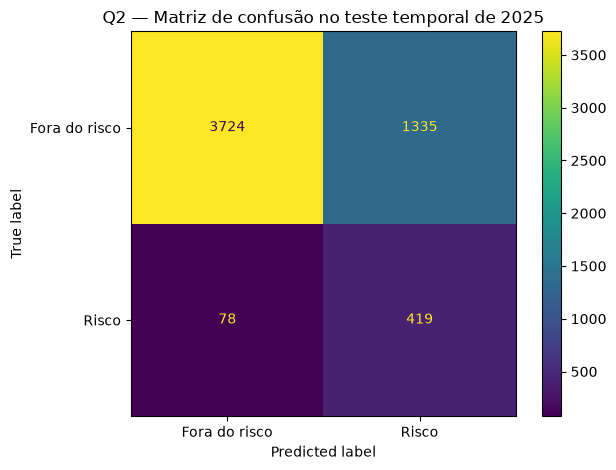

In [21]:
matriz_confusao_2025 = confusion_matrix(
    y_q2_2025,
    classe_prevista_2025,
    labels=[0, 1],
)

tn, fp, fn, tp = matriz_confusao_2025.ravel()

resumo_erros_2025 = pd.DataFrame({
    'tipo': [
        'Verdadeiro negativo (TN)',
        'Falso positivo (FP)',
        'Falso negativo (FN)',
        'Verdadeiro positivo (TP)',
    ],
    'municipios': [tn, fp, fn, tp],
})

display(resumo_erros_2025)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_2025,
    display_labels=['Fora do risco', 'Risco'],
).plot(values_format='d')

plt.title('Q2 — Matriz de confusão no teste temporal de 2025')
plt.grid(False)
plt.tight_layout()
plt.show()

## 13. Comparação direta — validação OOF de 2024 × teste temporal de 2025

Agora colocamos lado a lado duas avaliações fora da amostra de treinamento de cada previsão:

- **Validação OOF de 2024:** cada município de 2024 foi previsto por um modelo treinado nos outros folds. Ela
  representa a referência de desempenho dentro da janela de desenvolvimento, mas **não é um teste independente**.
- **Teste temporal de 2025:** o modelo ajustado em 100% de 2024 é aplicado a um período posterior. Esta é a
  avaliação final de **generalização temporal**.

A comparação utiliza o mesmo modelo e o mesmo threshold (`0,50`) nos dois períodos. Isso permite observar se a
qualidade da classificação se mantém quando a distribuição temporal muda.

A prevalência do risco caiu de aproximadamente **25,8% em 2024** para **8,9% em 2025**. Por isso, métricas
dependentes da prevalência — principalmente Precision, F1 e PR-AUC — devem ser interpretadas em conjunto com
Recall, ROC-AUC e as próprias matrizes de confusão.

Métricas comparativas — 2024 OOF × 2025 temporal


,periodo,Recall,Precision,F1,PR_AUC,ROC_AUC,Accuracy,Delta_Recall,Delta_Precision,Delta_F1,Delta_PR_AUC,Delta_ROC_AUC,Delta_Accuracy
0,Validação OOF 2024,0.775,0.608,0.681,0.739,0.882,0.813,0.000,0.000,0.000,0.000,0.000,0.000
1,Teste temporal 2025,0.843,0.239,0.372,0.409,0.867,0.746,0.068,-0.369,-0.309,-0.329,-0.016,-0.067


Contagens das matrizes de confusão


,periodo,TN,FP,FN,TP
0,Validação OOF 2024,3381,711,321,1104
1,Teste temporal 2025,3724,1335,78,419


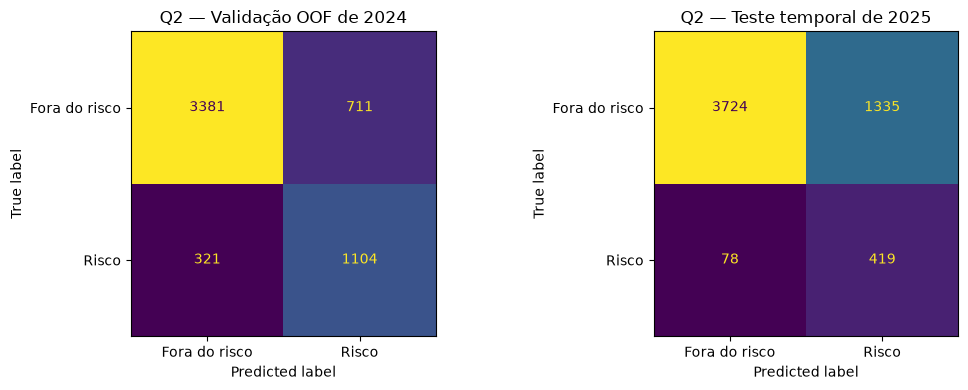

In [22]:
metricas_comparadas_q2 = [
    'Recall',
    'Precision',
    'F1',
    'PR_AUC',
    'ROC_AUC',
    'Accuracy',
]

comparacao_temporal_q2 = pd.DataFrame([
    {
        'periodo': 'Validação OOF 2024',
        **metricas_oof_2024,
    },
    {
        'periodo': 'Teste temporal 2025',
        **metricas_2025,
    },
])

for metrica in metricas_comparadas_q2:
    comparacao_temporal_q2[f'Delta_{metrica}'] = (
        comparacao_temporal_q2[metrica]
        - comparacao_temporal_q2.loc[
            comparacao_temporal_q2['periodo'].eq('Validação OOF 2024'),
            metrica,
        ].iloc[0]
    )

print('Métricas comparativas — 2024 OOF × 2025 temporal')
display(comparacao_temporal_q2.round(3))

comparacao_matrizes_q2 = pd.DataFrame([
    {
        'periodo': 'Validação OOF 2024',
        'TN': int(tn_2024),
        'FP': int(fp_2024),
        'FN': int(fn_2024),
        'TP': int(tp_2024),
    },
    {
        'periodo': 'Teste temporal 2025',
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
    },
])

print('Contagens das matrizes de confusão')
display(comparacao_matrizes_q2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_oof_2024,
    display_labels=['Fora do risco', 'Risco'],
).plot(
    ax=axes[0],
    values_format='d',
    colorbar=False,
)
axes[0].set_title('Q2 — Validação OOF de 2024')
axes[0].grid(False)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_2025,
    display_labels=['Fora do risco', 'Risco'],
).plot(
    ax=axes[1],
    values_format='d',
    colorbar=False,
)
axes[1].set_title('Q2 — Teste temporal de 2025')
axes[1].grid(False)

plt.tight_layout()
plt.show()

### 13.1 O que esta comparação permite concluir

A comparação entre 2024 e 2025 funciona como um **diagnóstico de estabilidade temporal**. Desempenho semelhante
nos dois períodos reforça a evidência de que o modelo preserva capacidade de generalização; deterioração relevante
indica que o comportamento preditivo mudou no período futuro.

Entretanto, a queda de desempenho **não identifica sozinha a causa**:

- **data drift** exige verificar se a distribuição das features mudou entre os anos;
- **concept drift** exige evidência de mudança na relação entre as features e o target;
- **overfitting** é avaliado principalmente pela diferença entre treino e validação/CV de 2024, e não apenas pela
  comparação 2024 × 2025.

Assim, as duas matrizes agregam valor como diagnóstico temporal, mas não devem ser tratadas isoladamente como
prova de *drift* ou sobreajuste.

## 14. Preparação das probabilidades para avaliação

Como a resposta final da Q2 será um ranking, preservamos a probabilidade prevista para cada município de 2025.

Ainda **não vamos ordenar nem publicar o Top 20**. Primeiro precisamos decidir se o desempenho temporal é suficientemente
confiável para justificar o uso dessas probabilidades como ferramenta de priorização.

In [23]:
resultado_temporal_q2 = chaves_q2_2025.copy()

assert 'nome_municipio' in resultado_temporal_q2.columns, (
    'A coluna nome_municipio não foi encontrada. Reexecute o notebook de preparação '
    'e gere novamente dados_modelagem_municipio_ano_2024_2025.parquet.'
)
assert resultado_temporal_q2['nome_municipio'].notna().all(), (
    'Existem municípios sem nome na base de teste de 2025.'
)

resultado_temporal_q2['risco_real'] = y_q2_2025.values
resultado_temporal_q2['probabilidade_risco'] = probabilidade_risco_2025
resultado_temporal_q2['classe_prevista'] = classe_prevista_2025

assert len(resultado_temporal_q2) == len(y_q2_2025)

print(f'Municípios com probabilidade calculada: {len(resultado_temporal_q2):,}')
print(
    'Probabilidade média prevista de risco: '
    f"{resultado_temporal_q2['probabilidade_risco'].mean():.3f}"
)

# Amostra identificada pelo nome do município.
display(
    resultado_temporal_q2[[
        'ano', 'nome_municipio', 'id_uf',
        'risco_real', 'probabilidade_risco', 'classe_prevista'
    ]].head()
)

Municípios com probabilidade calculada: 5,556
Probabilidade média prevista de risco: 0.344


,ano,nome_municipio,id_uf,risco_real,probabilidade_risco,classe_prevista
5517,2025,Alta Floresta D'Oeste,11,0,0.342,0
5518,2025,Ariquemes,11,0,0.250,0
5519,2025,Cabixi,11,0,0.298,0
5520,2025,Cacoal,11,0,0.288,0
5521,2025,Cerejeiras,11,0,0.226,0


## 15. Conclusão parcial — generalização temporal

O teste temporal de 2025 permite encerrar o terceiro ponto de decisão.

A **Regressão Logística balanceada** manteve boa capacidade de generalização temporal para identificar municípios em risco:

- **Recall = 0,843**;
- **ROC-AUC = 0,867**;
- **419 verdadeiros positivos**;
- **78 falsos negativos**.

O Recall aumentou em relação à validação cruzada de 2024 (`0,775 → 0,843`) e o ROC-AUC apresentou apenas pequena redução (`0,883 → 0,867`). Esses resultados indicam que o modelo continua identificando uma parcela relevante dos municípios realmente em risco e preserva boa capacidade de **ordenar municípios de maior e menor risco**.

Entretanto, houve uma mudança temporal importante na prevalência da classe positiva:

- **2024: 25,8%** dos municípios em risco;
- **2025: 8,9%** dos municípios em risco.

Nesse novo cenário, a **Precision caiu para 0,239**, com **1.335 falsos positivos**. Portanto, a classificação binária baseada no threshold padrão de `0,50` produz muitos alertas de risco que não correspondem à classe observada em 2025.

A comparação visual das matrizes OOF de 2024 e temporal de 2025 reforça esse diagnóstico: houve mudança relevante no perfil dos erros, especialmente pela queda de prevalência da classe de risco. Esse resultado é um **sinal de mudança temporal de desempenho**, mas não permite, por si só, distinguir *data drift* de *concept drift*. O sobreajuste, por sua vez, já foi analisado pela diferença entre treino e validação cruzada em 2024.

A PR-AUC de `0,409` também caiu em relação a 2024 (`0,741`), mas permanece substancialmente acima da prevalência positiva de 2025, indicando que ainda existe sinal útil para priorização da classe de risco.

### Decisão

Seguiremos pelo:

> **CAMINHO 1 — generalização suficiente para priorização.**

O modelo **não será utilizado como classificador definitivo de municípios em risco com base no threshold de 0,50**.

Para responder à Q2, utilizaremos `probabilidade_risco` como **escore de priorização**:

> **quanto maior a probabilidade estimada pelo modelo, maior a prioridade educacional atribuída ao município.**

Essa interpretação é mais adequada aos resultados porque o modelo apresentou Recall e ROC-AUC satisfatórios no teste temporal, mas Precision baixa.

As probabilidades também não devem ser interpretadas como certezas ou como probabilidades perfeitamente calibradas. Neste trabalho, seu principal uso será **ordenar os municípios segundo o risco estimado pelo modelo**.

### Limitação registrada

A redução da prevalência da classe de risco entre 2024 e 2025 provocou forte aumento relativo de falsos positivos. Essa limitação será mantida explicitamente na resposta final da Q2.

Não serão realizados:

- ajuste de threshold usando 2025;
- troca de modelo após observar 2025;
- tuning adicional da Regressão Logística;
- nova seleção de features baseada no desempenho de 2025.

Essas decisões preservam a separação temporal adotada no projeto.

### Próxima etapa

A modelagem está encerrada. A etapa seguinte será exclusivamente de resposta à Q2:

1. ordenar os municípios de 2025 por `probabilidade_risco` em ordem decrescente;
2. apresentar os municípios com maior risco estimado;
3. analisar objetivamente o topo do ranking;
4. registrar a limitação dos falsos positivos;
5. formular a conclusão final para:

> **Q2. Quais municípios apresentam maior risco educacional?**

# 16. Resposta final à Q2 — ranking de risco educacional

A modelagem está encerrada.

A Regressão Logística balanceada apresentou no teste temporal de 2025:

- **Recall = 0,843**;
- **ROC-AUC = 0,867**;
- **Precision = 0,239**;
- **419 verdadeiros positivos**;
- **78 falsos negativos**;
- **1.335 falsos positivos**.

Esses resultados sustentam o uso do modelo como ferramenta de **priorização**, mas não como classificador definitivo
baseado no threshold de `0,50`.

Por isso, a resposta à Q2 será construída a partir de `probabilidade_risco`, usada como **escore de risco estimado**:

> quanto maior o escore produzido pelo modelo, maior a prioridade educacional atribuída ao município.

A probabilidade não deve ser interpretada como certeza nem como probabilidade perfeitamente calibrada.
Seu uso aqui é principalmente **ordenar municípios de maior para menor risco estimado**.

## 16.1 Identificação territorial

O parquet de modelagem já contém `nome_municipio`, incorporado no notebook de preparação a partir do cadastro oficial de municípios.

Nesta etapa, `nome_municipio` é usado **somente como identificador descritivo**. Ele não participa do treinamento nem da previsão do modelo. Para complementar a leitura territorial, adicionamos a sigla da UF e a região a partir de `id_uf`.

In [24]:
mapa_sigla_uf = {
    11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO',
    21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL',
    28: 'SE', 29: 'BA',
    31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP',
    41: 'PR', 42: 'SC', 43: 'RS',
    50: 'MS', 51: 'MT', 52: 'GO', 53: 'DF',
}

mapa_regiao_uf = {
    11: 'Norte', 12: 'Norte', 13: 'Norte', 14: 'Norte',
    15: 'Norte', 16: 'Norte', 17: 'Norte',
    21: 'Nordeste', 22: 'Nordeste', 23: 'Nordeste', 24: 'Nordeste',
    25: 'Nordeste', 26: 'Nordeste', 27: 'Nordeste', 28: 'Nordeste', 29: 'Nordeste',
    31: 'Sudeste', 32: 'Sudeste', 33: 'Sudeste', 35: 'Sudeste',
    41: 'Sul', 42: 'Sul', 43: 'Sul',
    50: 'Centro-Oeste', 51: 'Centro-Oeste', 52: 'Centro-Oeste', 53: 'Centro-Oeste',
}

ranking_q2 = resultado_temporal_q2.copy()

ranking_q2['UF'] = ranking_q2['id_uf'].map(mapa_sigla_uf)
ranking_q2['regiao'] = ranking_q2['id_uf'].map(mapa_regiao_uf)

if ranking_q2['UF'].isna().any() or ranking_q2['regiao'].isna().any():
    ids_sem_mapa = sorted(
        ranking_q2.loc[
            ranking_q2['UF'].isna() | ranking_q2['regiao'].isna(),
            'id_uf'
        ].dropna().unique().tolist()
    )
    raise ValueError(f'Existem UFs sem mapeamento: {ids_sem_mapa}')

ranking_q2 = (
    ranking_q2
    .sort_values('probabilidade_risco', ascending=False)
    .reset_index(drop=True)
)

ranking_q2.insert(0, 'posicao_risco', ranking_q2.index + 1)

print(f'Municípios ranqueados: {len(ranking_q2):,}')

Municípios ranqueados: 5,556


## 16.2 Municípios com maior risco estimado

A tabela abaixo apresenta os **20 municípios com maior escore de risco educacional em 2025**, identificados diretamente pelo nome do município.

`risco_real` é mantido apenas para auditoria do teste temporal:

- `1`: taxa realizada inferior a 50%;
- `0`: taxa realizada igual ou superior a 50%.

A ordenação é feita exclusivamente por `probabilidade_risco`, e não pela classe observada.

In [25]:
colunas_ranking = [
    'posicao_risco',
    'nome_municipio',
    'UF',
    'regiao',
    'probabilidade_risco',
    'risco_real',
    'classe_prevista',
]

TOP_N_Q2 = 20
top20_q2 = ranking_q2.loc[:, colunas_ranking].head(TOP_N_Q2).copy()

display(
    top20_q2.style.format({
        'probabilidade_risco': '{:.3f}',
    })
)

,posicao_risco,nome_municipio,UF,regiao,probabilidade_risco,risco_real,classe_prevista
0,1,Jardim de Angicos,RN,Nordeste,0.995,1,1
1,2,Curralinho,PA,Norte,0.995,1,1
2,3,Melgaço,PA,Norte,0.995,1,1
3,4,Lagoa d'Anta,RN,Nordeste,0.992,1,1
4,5,Paraú,RN,Nordeste,0.992,1,1
5,6,Triunfo Potiguar,RN,Nordeste,0.991,1,1
6,7,Eirunepé,AM,Norte,0.989,1,1
7,8,Envira,AM,Norte,0.989,0,1
8,9,Japi,RN,Nordeste,0.989,1,1
9,10,Ruy Barbosa,RN,Nordeste,0.989,0,1


## 16.3 Leitura objetiva do Top 20

Como o modelo foi escolhido para **priorização**, verificamos de forma descritiva:

- quantos municípios do Top 20 realmente estavam em risco em 2025;
- quantos eram falsos positivos no threshold de `0,50`;
- quais UFs e regiões aparecem com maior frequência no topo.

Essa análise não modifica o modelo nem cria novas regras de classificação.

In [26]:
resumo_top20_q2 = pd.DataFrame({
    'indicador': [
        'Municípios no Top 20',
        'Realmente em risco em 2025',
        'Fora do risco em 2025',
        'Percentual realmente em risco no Top 20',
    ],
    'valor': [
        len(top20_q2),
        int(top20_q2['risco_real'].sum()),
        int((top20_q2['risco_real'] == 0).sum()),
        float(top20_q2['risco_real'].mean() * 100),
    ],
})

display(resumo_top20_q2)

print('Top 20 por UF:')
display(
    top20_q2['UF']
    .value_counts()
    .rename_axis('UF')
    .reset_index(name='municipios_top20')
)

print('Top 20 por região:')
display(
    top20_q2['regiao']
    .value_counts()
    .rename_axis('regiao')
    .reset_index(name='municipios_top20')
)

,indicador,valor
0,Municípios no Top 20,20.000
1,Realmente em risco em 2025,13.000
2,Fora do risco em 2025,7.000
3,Percentual realmente em risco no Top 20,65.000


Top 20 por UF:


,UF,municipios_top20
0,RN,11
1,PA,4
2,AM,3
3,BA,2


Top 20 por região:


,regiao,municipios_top20
0,Nordeste,13
1,Norte,7


## 16.4 Distribuição territorial do grupo de maior prioridade

O Top 20 é útil para responder diretamente à pergunta, mas é uma lista pequena.

Como complemento descritivo, observamos os **100 municípios com maior escore** para verificar se a concentração territorial
do topo permanece quando ampliamos o grupo de prioridade.

Não utilizamos essa análise para alterar o modelo ou definir um novo threshold.

In [27]:
TOP_PRIORIDADE_Q2 = 100
top100_q2 = ranking_q2.head(TOP_PRIORIDADE_Q2).copy()

resumo_uf_top100 = (
    top100_q2
    .groupby(['UF', 'regiao'])
    .size()
    .rename('municipios_top100')
    .reset_index()
    .sort_values('municipios_top100', ascending=False)
)

resumo_regiao_top100 = (
    top100_q2
    .groupby('regiao')
    .size()
    .rename('municipios_top100')
    .reset_index()
    .sort_values('municipios_top100', ascending=False)
)

print('Distribuição do Top 100 por UF:')
display(resumo_uf_top100)

print('Distribuição do Top 100 por região:')
display(resumo_regiao_top100)

Distribuição do Top 100 por UF:


,UF,regiao,municipios_top100
4,RN,Nordeste,41
2,BA,Nordeste,27
3,PA,Norte,8
1,AM,Norte,7
5,RS,Sul,7
6,SE,Nordeste,6
0,AC,Norte,2
7,TO,Norte,2


Distribuição do Top 100 por região:


,regiao,municipios_top100
0,Nordeste,74
1,Norte,19
2,Sul,7


In [28]:
# Resposta nominal da Q2
nomes_top20 = top20_q2['nome_municipio'].tolist()

print('Municípios com maior risco educacional estimado em 2025:')
for posicao, nome in enumerate(nomes_top20, start=1):
    linha = top20_q2.iloc[posicao - 1]
    print(
        f"{posicao:>2}. {nome} ({linha['UF']}) — "
        f"escore de risco: {linha['probabilidade_risco']:.3f}"
    )


Municípios com maior risco educacional estimado em 2025:
 1. Jardim de Angicos (RN) — escore de risco: 0.995
 2. Curralinho (PA) — escore de risco: 0.995
 3. Melgaço (PA) — escore de risco: 0.995
 4. Lagoa d'Anta (RN) — escore de risco: 0.992
 5. Paraú (RN) — escore de risco: 0.992
 6. Triunfo Potiguar (RN) — escore de risco: 0.991
 7. Eirunepé (AM) — escore de risco: 0.989
 8. Envira (AM) — escore de risco: 0.989
 9. Japi (RN) — escore de risco: 0.989
10. Ruy Barbosa (RN) — escore de risco: 0.989
11. Juruá (AM) — escore de risco: 0.988
12. Arataca (BA) — escore de risco: 0.988
13. Pedro Velho (RN) — escore de risco: 0.988
14. Rio do Fogo (RN) — escore de risco: 0.987
15. Lagoa de Pedras (RN) — escore de risco: 0.987
16. Poço Branco (RN) — escore de risco: 0.986
17. Oeiras do Pará (PA) — escore de risco: 0.986
18. Itanagra (BA) — escore de risco: 0.985
19. Januário Cicco (RN) — escore de risco: 0.985
20. Garrafão do Norte (PA) — escore de risco: 0.984


In [29]:
# Resposta nominal à Q2
TOP_N_RESPOSTA_Q2 = 20

resposta_q2 = (
    ranking_q2
    .loc[:, [
        'posicao_risco',
        'nome_municipio',
        'UF',
        'regiao',
        'probabilidade_risco',
        'risco_real',
    ]]
    .head(TOP_N_RESPOSTA_Q2)
    .copy()
)

print('Q2 — Quais municípios apresentam maior risco educacional?\n')
print(
    'Segundo a Regressão Logística balanceada, os municípios de maior '
    'prioridade educacional em 2025 são:\n'
)

for _, linha in resposta_q2.iterrows():
    print(
        f"{int(linha['posicao_risco']):>2}. "
        f"{linha['nome_municipio']} ({linha['UF']}) — "
        f"escore de risco: {linha['probabilidade_risco']:.3f}"
    )

print(
    '\nInterpretação: a lista está ordenada pela probabilidade_risco. '
    'Esse valor é utilizado como escore de priorização e não como '
    'diagnóstico definitivo de risco.'
)

Q2 — Quais municípios apresentam maior risco educacional?

Segundo a Regressão Logística balanceada, os municípios de maior prioridade educacional em 2025 são:

 1. Jardim de Angicos (RN) — escore de risco: 0.995
 2. Curralinho (PA) — escore de risco: 0.995
 3. Melgaço (PA) — escore de risco: 0.995
 4. Lagoa d'Anta (RN) — escore de risco: 0.992
 5. Paraú (RN) — escore de risco: 0.992
 6. Triunfo Potiguar (RN) — escore de risco: 0.991
 7. Eirunepé (AM) — escore de risco: 0.989
 8. Envira (AM) — escore de risco: 0.989
 9. Japi (RN) — escore de risco: 0.989
10. Ruy Barbosa (RN) — escore de risco: 0.989
11. Juruá (AM) — escore de risco: 0.988
12. Arataca (BA) — escore de risco: 0.988
13. Pedro Velho (RN) — escore de risco: 0.988
14. Rio do Fogo (RN) — escore de risco: 0.987
15. Lagoa de Pedras (RN) — escore de risco: 0.987
16. Poço Branco (RN) — escore de risco: 0.986
17. Oeiras do Pará (PA) — escore de risco: 0.986
18. Itanagra (BA) — escore de risco: 0.985
19. Januário Cicco (RN) — escor

## 17. Interpretação da Regressão Logística — coeficientes padronizados

A Regressão Logística balanceada foi ajustada em 100% dos dados válidos de 2024 dentro do `Pipeline` já utilizado no teste temporal.

No ramo numérico do preprocessing, as variáveis passam por imputação pela mediana e `StandardScaler`. Portanto, os coeficientes associados aos termos numéricos podem ser comparados em uma escala comum.

Como o `SimpleImputer` de Q2 foi configurado com `add_indicator=True`, o modelo também pode conter termos `missingindicator_*`, que representam a presença de valores ausentes nas respectivas variáveis. Esses termos fazem parte do modelo ajustado e, por isso, são mantidos na tabela de coeficientes.

A leitura será:

- coeficiente **positivo** → associado a aumento do escore de risco educacional;
- coeficiente **negativo** → associado a redução do escore de risco educacional;
- maior valor absoluto → maior peso na decisão linear do modelo.

Essa interpretação é **preditiva**, não causal.

Não devemos escrever que uma variável causa o risco educacional. O correto é dizer que ela está associada a maior ou menor risco estimado pelo modelo.

In [30]:
preprocessador_final_q2 = MODELO_ESCOLHIDO_Q2.named_steps['preprocessor']
modelo_logistico_final_q2 = MODELO_ESCOLHIDO_Q2.named_steps['model']

nomes_features_transformadas_q2 = (
    preprocessador_final_q2
    .get_feature_names_out()
)

# O ColumnTransformer adiciona os prefixos "num__" e "cat__".
nomes_features_limpas_q2 = [
    nome.replace('num__', '', 1).replace('cat__', '', 1)
    for nome in nomes_features_transformadas_q2
]

coeficientes_q2 = modelo_logistico_final_q2.coef_.ravel()

assert len(nomes_features_limpas_q2) == len(coeficientes_q2)

tabela_coeficientes_q2 = pd.DataFrame({
    'feature': nomes_features_limpas_q2,
    'coeficiente': coeficientes_q2,
})

tabela_coeficientes_q2['coeficiente_abs'] = (
    tabela_coeficientes_q2['coeficiente'].abs()
)

tabela_coeficientes_q2['direcao'] = np.where(
    tabela_coeficientes_q2['coeficiente'] > 0,
    'Aumenta o risco estimado',
    'Reduz o risco estimado',
)

tabela_coeficientes_q2 = (
    tabela_coeficientes_q2
    .sort_values(
        'coeficiente_abs',
        ascending=False,
    )
    .reset_index(drop=True)
)

print('Principais coeficientes em valor absoluto:')
display(
    tabela_coeficientes_q2
    .head(20)
    .round(4)
)

Principais coeficientes em valor absoluto:


,feature,coeficiente,coeficiente_abs,direcao
0,ctx_inep_uf_media_portugues_lag1,-1.232,1.232,Reduz o risco estimado
1,proficiencia_lag1,-0.776,0.776,Reduz o risco estimado
2,ctx_atlas_taxa_analfabetismo_11a14,0.528,0.528,Aumenta o risco estimado
3,participacao_lag1,-0.371,0.371,Reduz o risco estimado
4,ctx_atlas_taxa_fora_escola_4a5,0.256,0.256,Aumenta o risco estimado
5,ctx_inep_uf_percentual_participacao_lag1,-0.193,0.193,Reduz o risco estimado
6,ctx_atu_fundamental_5_ano,-0.178,0.178,Reduz o risco estimado
7,ctx_atu_pre_escola,-0.177,0.177,Reduz o risco estimado
8,ctx_atlas_taxa_analfabetismo_15mais,-0.163,0.163,Reduz o risco estimado
9,ctx_atu_fundamental_3_ano,0.156,0.156,Aumenta o risco estimado


In [31]:
print('Top 10 coeficientes positivos — associados a maior risco estimado:')
display(
    tabela_coeficientes_q2
    .sort_values('coeficiente', ascending=False)
    .head(10)[
        ['feature', 'coeficiente', 'direcao']
    ]
    .round(4)
)

print('\nTop 10 coeficientes negativos — associados a menor risco estimado:')
display(
    tabela_coeficientes_q2
    .sort_values('coeficiente', ascending=True)
    .head(10)[
        ['feature', 'coeficiente', 'direcao']
    ]
    .round(4)
)

Top 10 coeficientes positivos — associados a maior risco estimado:


,feature,coeficiente,direcao
2,ctx_atlas_taxa_analfabetismo_11a14,0.528,Aumenta o risco estimado
4,ctx_atlas_taxa_fora_escola_4a5,0.256,Aumenta o risco estimado
9,ctx_atu_fundamental_3_ano,0.156,Aumenta o risco estimado
13,missingindicator_participacao_lag1,0.150,Aumenta o risco estimado
14,ctx_atlas_expectativa_anos_estudo,0.140,Aumenta o risco estimado
15,ctx_atlas_taxa_frequencia_liquida_fundamental,0.129,Aumenta o risco estimado
19,missingindicator_ctx_atu_educacao_infantil,0.097,Aumenta o risco estimado
21,ctx_fundeb_nse_uf,0.092,Aumenta o risco estimado
22,ctx_atlas_taxa_maes_chefes_familia,0.087,Aumenta o risco estimado
23,missingindicator_ctx_inep_uf_media_portugues_lag1,0.082,Aumenta o risco estimado



Top 10 coeficientes negativos — associados a menor risco estimado:


,feature,coeficiente,direcao
0,ctx_inep_uf_media_portugues_lag1,-1.232,Reduz o risco estimado
1,proficiencia_lag1,-0.776,Reduz o risco estimado
3,participacao_lag1,-0.371,Reduz o risco estimado
5,ctx_inep_uf_percentual_participacao_lag1,-0.193,Reduz o risco estimado
6,ctx_atu_fundamental_5_ano,-0.178,Reduz o risco estimado
7,ctx_atu_pre_escola,-0.177,Reduz o risco estimado
8,ctx_atlas_taxa_analfabetismo_15mais,-0.163,Reduz o risco estimado
10,ctx_atlas_idhm_longevidade,-0.152,Reduz o risco estimado
11,missingindicator_ctx_atu_fundamental_3_ano,-0.152,Reduz o risco estimado
12,taxa_lag1,-0.151,Reduz o risco estimado


# Conclusão — Q2. Quais municípios apresentam maior risco educacional?

A resposta à Q2 é dada pelo **ranking nominal apresentado acima**, ordenado por `probabilidade_risco`. Assim, os municípios que aparecem nas primeiras posições são aqueles que o modelo considera de **maior prioridade educacional em 2025**.

A Q2 foi modelada como um problema de classificação binária, considerando em risco o município com taxa de alfabetização inferior a 50%. Entre os modelos avaliados com dados de 2024, foi selecionada a **Regressão Logística balanceada**, priorizando a identificação dos municípios realmente em risco.

No teste temporal de 2025, o modelo alcançou **Recall de 0,843** e **ROC-AUC de 0,867**, preservando boa capacidade de identificação e de ordenação dos municípios. Entretanto, a prevalência do risco caiu de **25,8% em 2024 para 8,9% em 2025**, enquanto a **Precision caiu para 0,239**, com **1.335 falsos positivos**.

Por esse motivo, os municípios classificados como positivos com threshold de `0,50` não devem ser interpretados automaticamente como casos confirmados de risco. A variável `probabilidade_risco` é utilizada como **escore de priorização**: quanto maior seu valor, maior a prioridade atribuída pelo modelo.

A análise dos coeficientes padronizados da Regressão Logística também permite identificar quais variáveis possuem maior peso na classificação. As de maior magnitude absoluta foram:

* `ctx_inep_uf_media_portugues_lag1`: **-1,232**;
* `proficiencia_lag1`: **-0,776**;
* `ctx_atlas_taxa_analfabetismo_11a14`: **+0,528**;
* `participacao_lag1`: **-0,371**;
* `ctx_atlas_taxa_fora_escola_4a5`: **+0,256**;
* `ctx_inep_uf_percentual_participacao_lag1`: **-0,193**.

Como as variáveis numéricas foram padronizadas, a magnitude dos coeficientes permite comparar seu peso relativo no modelo. Coeficientes negativos estão associados à redução do escore estimado de risco, enquanto coeficientes positivos estão associados ao seu aumento.

Nesse sentido, maiores níveis anteriores de desempenho em Língua Portuguesa na UF, maior proficiência do município e maior participação estão associados a **menor risco educacional previsto**. Em sentido oposto, maiores taxas de analfabetismo entre 11 e 14 anos e de crianças de 4 a 5 anos fora da escola estão associadas a **maior risco previsto**.

Portanto:

> **Os municípios com maior risco educacional são aqueles nominalmente apresentados no topo do ranking, em ordem decrescente de `probabilidade_risco`. O modelo indica que esse risco está associado principalmente ao desempenho educacional anterior, à participação e a indicadores de vulnerabilidade educacional. Os municípios identificados devem ser interpretados como prioridades para acompanhamento e investigação, e não como diagnósticos definitivos de baixa alfabetização.**

O nome do município é utilizado somente para identificação e apresentação dos resultados. `nome_municipio`, `id_municipio`, `id_uf` e `ano` **não participam como features preditivas**.

A baixa Precision e o número de falsos positivos permanecem como limitações explícitas da modelagem. Além disso, os coeficientes representam **associações preditivas do modelo, e não relações causais**.

Assim, a Q2 fornece simultaneamente dois resultados: **um ranking de municípios para priorização educacional** e uma indicação das **variáveis que mais contribuem para a classificação de risco**.
